# GPU/LLM batch-service SLA: the exact tail vs the moment-fit approximation

A continuous-batching inference server (GPU/LLM serving) waits until at least `a` requests
have queued, then dispatches a batch of up to `b_max` together -- `M/G^[a,b_max]/1` bulk
service. "Will this request miss its deadline?" is a question about the **tail**
`P(W > D)` of the waiting time, not its mean.

Elsewhere in this library (see `llm_serving_slo.ipynb`), `most_queue.theory.utils.sla`
turns a few raw **moments** of `W` into an estimated violation probability by fitting a
2-3 moment distribution (H2/Gamma) to them -- a good approximation for an ordinary queue.
Here we feed it the *exact same* moments as a **bounded** batch-service model
(`BulkServiceErlangCalc`), which also gives the **true** tail directly from its
phase-type CTMC (`get_tail`), no fitting involved.

**Same moments in, wildly different deep-tail answer out.** The discrepancy isn't about
missing information -- it's that a 2-3 moment fit assumes a tail *shape* the bounded
window doesn't actually have.

In [1]:
import matplotlib.pyplot as plt

from most_queue.theory.batch.bulk_service_erlang import BulkServiceErlangCalc
from most_queue.theory.utils.sla import deadline_violation_prob

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 11})

# Same prescribed parameters as the article's own study (Inoue 2021, Table 1(a)/Fig. 9
# least-squares fit, Tesla V100 ResNet50 -- see examples/batch_service_sla_exact_tail_comparison.py).
ALPHA, TAU0 = 0.1438, 1.8874   # mean batch-service time = ALPHA*batch_size + TAU0
LAM = 0.8                      # arrival rate; stable for every b_max tested below
ERLANG_K = 10                  # CV = 1/sqrt(10) = 0.316 -- a low-variance, near-deterministic service
QUEUE_TRUNCATION = 400

def erlang_rate_fn(size):
    """Per-phase Erlang rate giving mean batch time ALPHA*size + TAU0 at k=ERLANG_K phases."""
    return ERLANG_K / (ALPHA * size + TAU0)

print(f"rho = lambda*alpha = {LAM * ALPHA:.3f}  (stable, < 1)")

rho = lambda*alpha = 0.115  (stable, < 1)

## One batch window, three deadlines

Fix `b_max = 8` (dispatch up to 8 requests per batch). Compute the waiting-time moments
once with the exact calculator, then compare the **exact** tail (`get_tail`, from the
real phase-type CTMC) against the **fitted** tail (`deadline_violation_prob`, fed the
exact same moments) at three deadlines.

In [2]:
B_MAX = 8
DEADLINES = (5.0, 10.0, 20.0)

calc = BulkServiceErlangCalc(a=1, b=B_MAX, k=ERLANG_K, queue_truncation=QUEUE_TRUNCATION)
calc.set_sources(LAM)
calc.set_servers(erlang_rate_fn)
w_moments = calc.get_w(num=2)
print(f"E[W] = {w_moments[0]:.3f}   (moments are IDENTICAL for both methods below)\n")

print(f"{'D':>6} {'exact P(W>D)':>14} {'fitted P(W>D)':>15} {'fitted / exact':>16}")
for d in DEADLINES:
    exact = calc.get_tail(d)
    fitted = deadline_violation_prob(w_moments, d)
    print(f"{d:6.1f} {exact:14.3e} {fitted:15.3e} {fitted / exact:16,.3g}")

E[W] = 1.074   (moments are IDENTICAL for both methods below)


     D   exact P(W>D)   fitted P(W>D)   fitted / exact

   5.0      2.739e-04       2.530e-03             9.24

  10.0      5.680e-09       2.463e-06              434

  20.0      3.364e-18       1.657e-12         4.93e+05

At `D=5` the fit is a reasonable approximation. By `D=20` it overstates the true
violation probability by **~5 orders of magnitude**. The fit isn't missing data -- it
has the exact same mean and variance as the true model. It assumes a tail *shape*
(H2/Gamma) that decays far slower than the real bounded-window system's, and the
deeper into the tail you look, the more that shape assumption -- not the moments --
determines the answer.

## Does it get better or worse with a bigger batch window?

Sweep `b_max` at a fixed deadline `D=10` and watch the ratio.

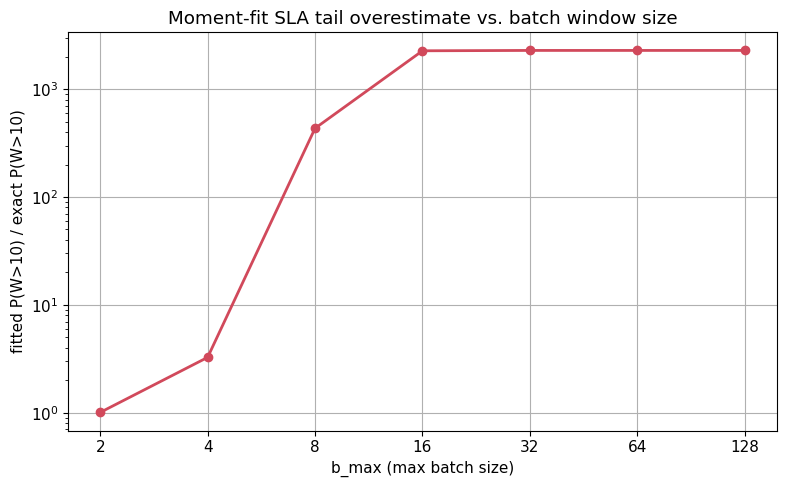

b_max=   2  E[W]= 5.005  fitted/exact at D=10 = 1.01

b_max=   4  E[W]= 1.196  fitted/exact at D=10 = 3.26

b_max=   8  E[W]= 1.074  fitted/exact at D=10 = 434

b_max=  16  E[W]= 1.073  fitted/exact at D=10 = 2.27e+03

b_max=  32  E[W]= 1.073  fitted/exact at D=10 = 2.29e+03

b_max=  64  E[W]= 1.073  fitted/exact at D=10 = 2.29e+03

b_max= 128  E[W]= 1.073  fitted/exact at D=10 = 2.29e+03

In [3]:
B_MAX_VALUES = (2, 4, 8, 16, 32, 64, 128)
D = 10.0

ratios, means = [], []
for b in B_MAX_VALUES:
    c = BulkServiceErlangCalc(a=1, b=b, k=ERLANG_K, queue_truncation=QUEUE_TRUNCATION)
    c.set_sources(LAM)
    c.set_servers(erlang_rate_fn)
    wm = c.get_w(num=2)
    exact = c.get_tail(D)
    fitted = deadline_violation_prob(wm, D)
    ratios.append(fitted / exact)
    means.append(wm[0])

fig, ax = plt.subplots()
ax.semilogy(B_MAX_VALUES, ratios, color="#d1495b", marker="o", lw=2)
ax.set_xscale("log", base=2)
ax.set_xticks(B_MAX_VALUES)
ax.set_xticklabels([str(b) for b in B_MAX_VALUES])
ax.set_xlabel("b_max (max batch size)")
ax.set_ylabel(f"fitted P(W>{D:.0f}) / exact P(W>{D:.0f})")
ax.set_title("Moment-fit SLA tail overestimate vs. batch window size")
plt.tight_layout()
plt.show()

for b, r, m in zip(B_MAX_VALUES, ratios, means):
    print(f"b_max={b:4}  E[W]={m:6.3f}  fitted/exact at D={D:.0f} = {r:,.3g}")

**The insight.** The overestimate grows sharply as `b_max` increases past the
dispatch threshold `a=1`, then plateaus once the window is wide enough that the queue
almost never fills it -- past that point, widening `b_max` further changes nothing
about the tail. At the same time, `E[W]` keeps improving as `b_max` grows (bigger
batches amortize the fixed `TAU0` overhead): **the mean looks like it's only getting
better, while the moment-fit estimate of deep-tail SLA risk silently decouples from
reality by orders of magnitude**, in the *safe* (overly pessimistic, not
dangerously optimistic) direction here -- but a fit you can't quantify the error of is
not a fit you should plan capacity around.

## Takeaway

For a **bounded** continuous-batching window (GPU/LLM inference, `b_max` capped by
memory or latency budget), prefer `BulkServiceErlangCalc`/`BulkServiceH2Calc.get_tail()`
-- the exact phase-type result -- over the generic moment-fit SLA layer
(`most_queue.theory.utils.sla`), which was designed for queues without that bound and
can misjudge deep-tail risk by orders of magnitude once one is imposed. The moment-fit
layer remains a fine choice for shallow deadlines or genuinely unbounded service (see
`llm_serving_slo.ipynb`).

See also: [`docs/research/batch-service-sla-exact-tail-2026.md`](../docs/research/batch-service-sla-exact-tail-2026.md),
[`examples/batch_service_sla_exact_tail_comparison.py`](../examples/batch_service_sla_exact_tail_comparison.py),
and the [bulk-service model docs](../docs/models/batch.md).